Import important packages

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Connect Google Drive

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import dataset

In [26]:
df = pd.read_csv('/content/drive/MyDrive/220125_AI_ML/Task_2/Student_Performance.csv')

In [27]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


Check column types and missing values

In [28]:

print("=== Data Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB
None

=== Missing Values ===
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

=== Basic Statistics ===


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


Convert 'Extracurricular Activities' from Yes/No text to 1/0 numbers


In [29]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

print("After encoding:")
df.head()

After encoding:


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


Style for plot

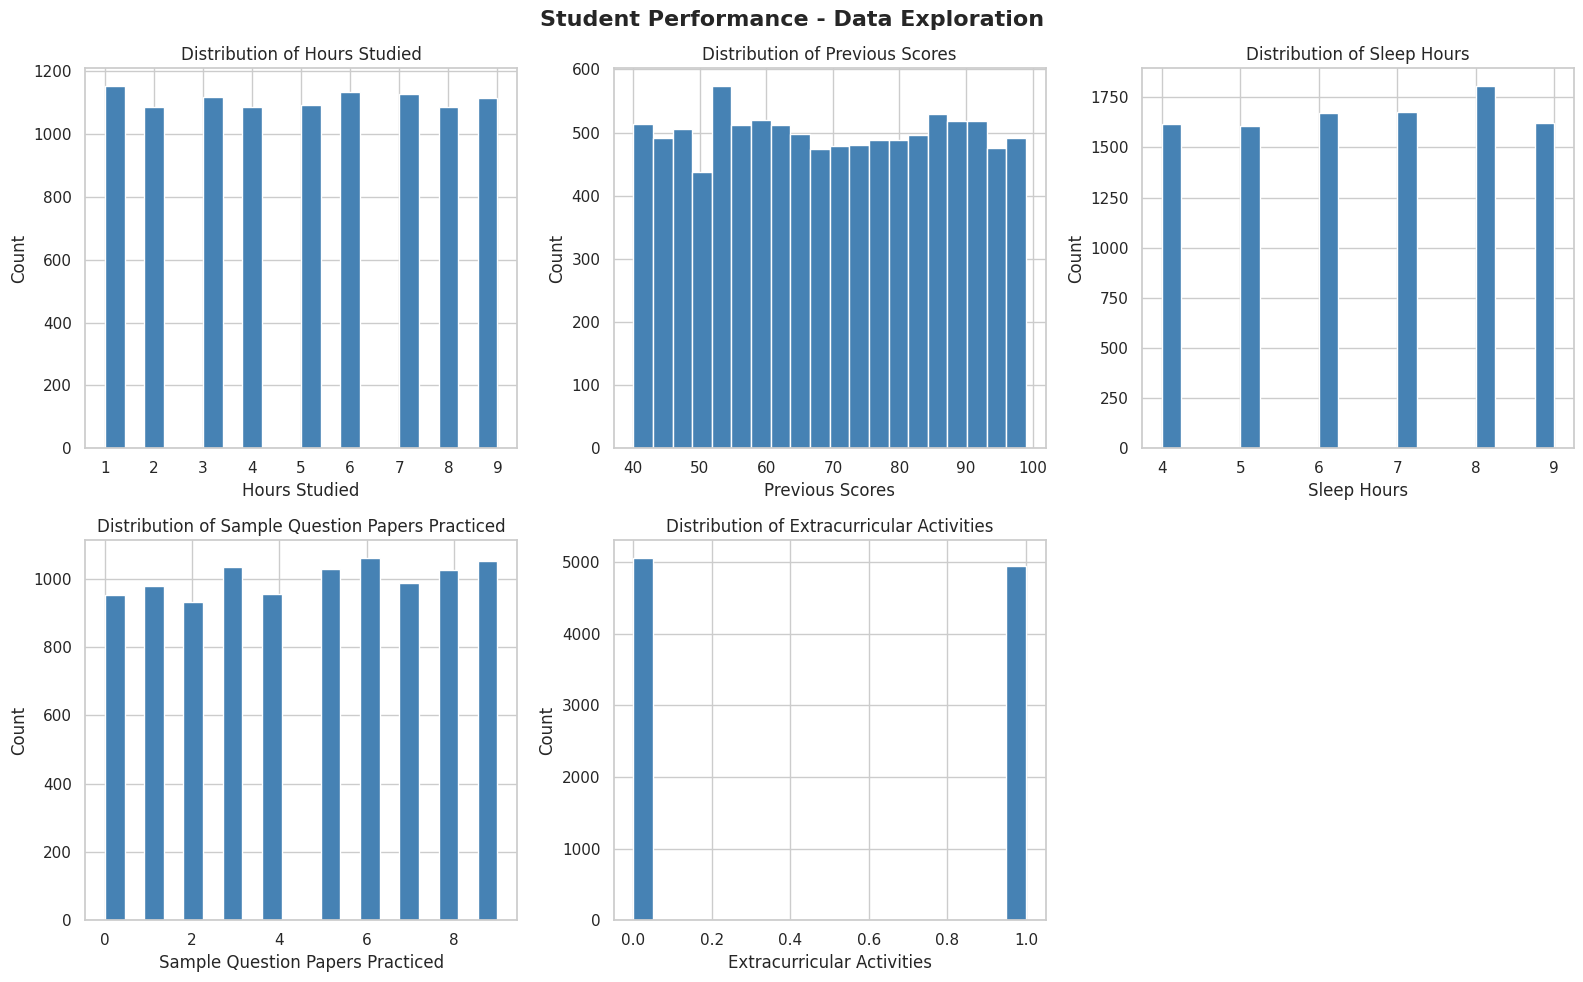

In [30]:

sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Student Performance - Data Exploration', fontsize=16, fontweight='bold')

cols = ['Hours Studied', 'Previous Scores', 'Sleep Hours',
        'Sample Question Papers Practiced', 'Extracurricular Activities']

for i, col in enumerate(cols):
    ax = axes[i // 3][i % 3]
    ax.hist(df[col], bins=20, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')


axes[1][2].set_visible(False)
plt.tight_layout()
plt.show()

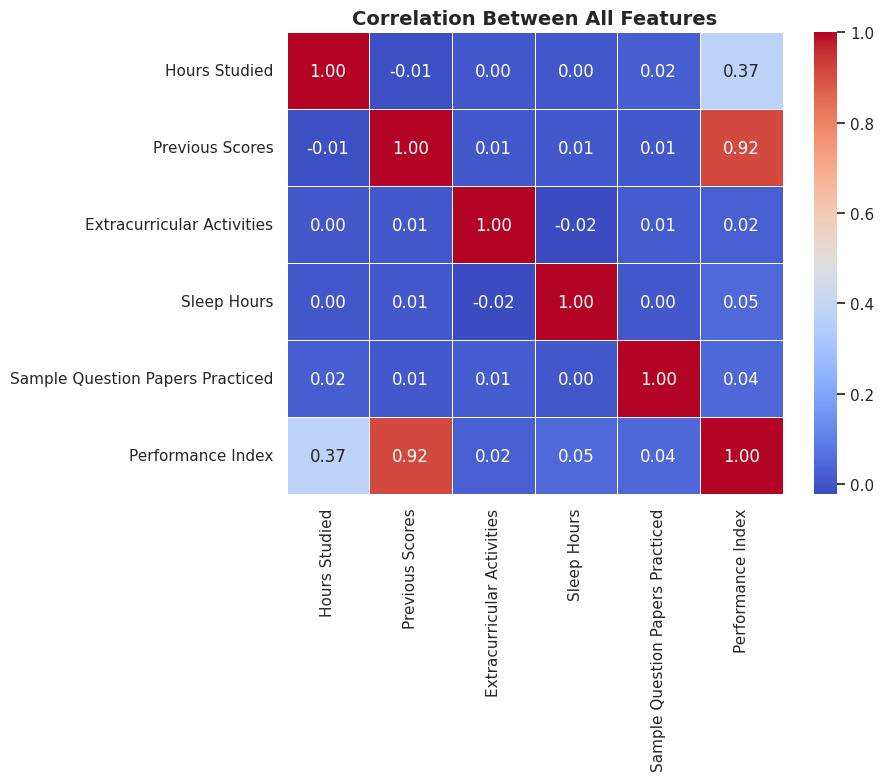

In [31]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Between All Features', fontsize=14, fontweight='bold')
plt.show()

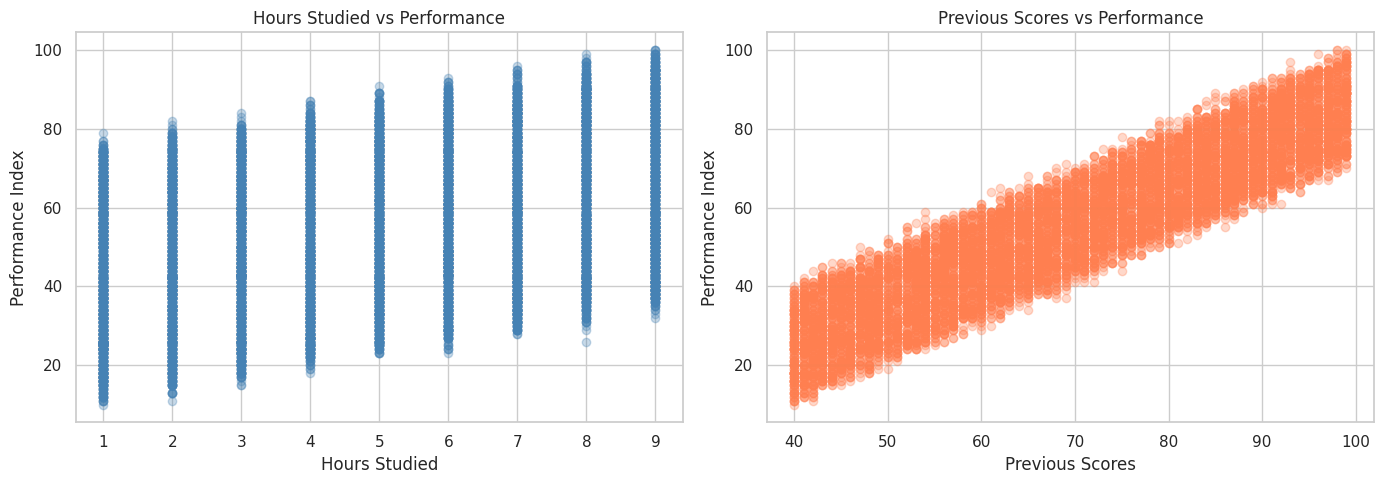

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Hours Studied'], df['Performance Index'], alpha=0.3, color='steelblue')
axes[0].set_xlabel('Hours Studied')
axes[0].set_ylabel('Performance Index')
axes[0].set_title('Hours Studied vs Performance')

axes[1].scatter(df['Previous Scores'], df['Performance Index'], alpha=0.3, color='coral')
axes[1].set_xlabel('Previous Scores')
axes[1].set_ylabel('Performance Index')
axes[1].set_title('Previous Scores vs Performance')

plt.tight_layout()
plt.show()

Input and Output

In [33]:

X = df.drop(columns=['Performance Index'])
y = df['Performance Index']

print("Input features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", list(X.columns))

Input features shape: (10000, 5)
Target shape: (10000,)

Feature columns: ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples: 8000
Testing samples:  2000


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done! Sample of scaled training data:")
print(X_train_scaled[:3])

Scaling done! Sample of scaled training data:
[[ 0.00645547 -1.18384439 -0.98930717  0.26988848  0.13404112]
 [-1.14974745 -1.24150571  1.01080841  0.26988848  0.48356164]
 [-1.14974745  0.66131759 -0.98930717  0.26988848 -0.91452044]]


Create the model and train it

In [36]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()

model.fit(X_train_scaled, y_train)

print("Model trained successfully!")
print("\nModel Coefficients (weights for each feature):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")

print(f"\nIntercept: {model.intercept_:.4f}")

Model trained successfully!

Model Coefficients (weights for each feature):
  Hours Studied: 7.4013
  Previous Scores: 17.6373
  Extracurricular Activities: 0.3043
  Sleep Hours: 0.8100
  Sample Question Papers Practiced: 0.5488

Intercept: 55.3115


Predictions on test data and calculate the metrices

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test_scaled)


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("===== Model Evaluation =====")
print(f"MAE  (Mean Absolute Error)  : {mae:.4f}")
print(f"MSE  (Mean Squared Error)   : {mse:.4f}")
print(f"RMSE (Root Mean Sq. Error)  : {rmse:.4f}")
print(f"R²   (R-Squared Score)      : {r2:.4f}")

===== Model Evaluation =====
MAE  (Mean Absolute Error)  : 1.6111
MSE  (Mean Squared Error)   : 4.0826
RMSE (Root Mean Sq. Error)  : 2.0206
R²   (R-Squared Score)      : 0.9890


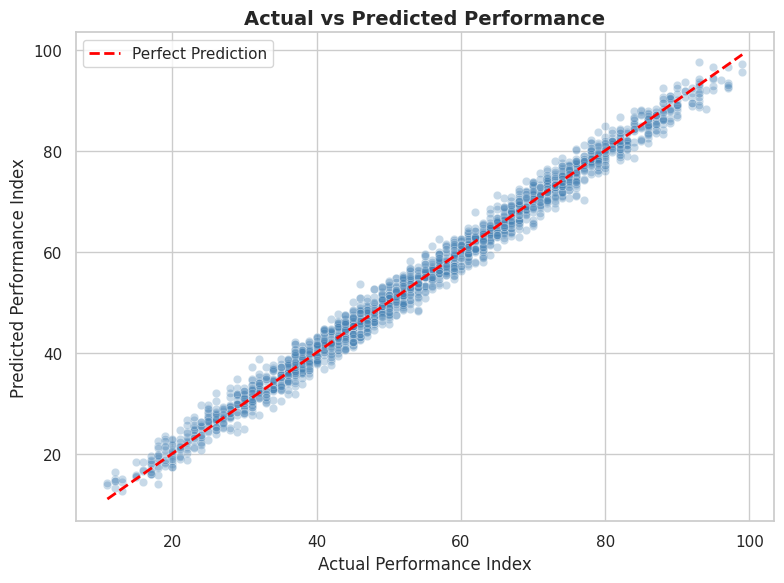

In [38]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Performance Index', fontsize=12)
plt.ylabel('Predicted Performance Index', fontsize=12)
plt.title('Actual vs Predicted Performance', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

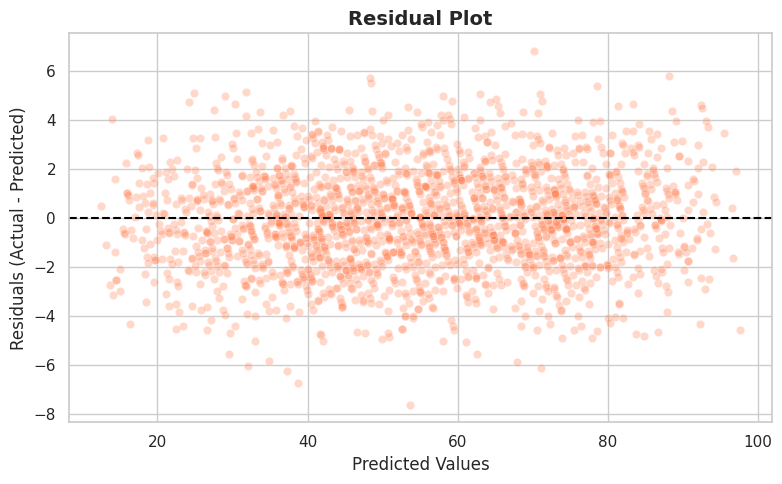

In [39]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.3, color='coral', edgecolors='white', linewidth=0.5)
plt.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.title('Residual Plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Simulate a loss curve by training on increasing portions of data

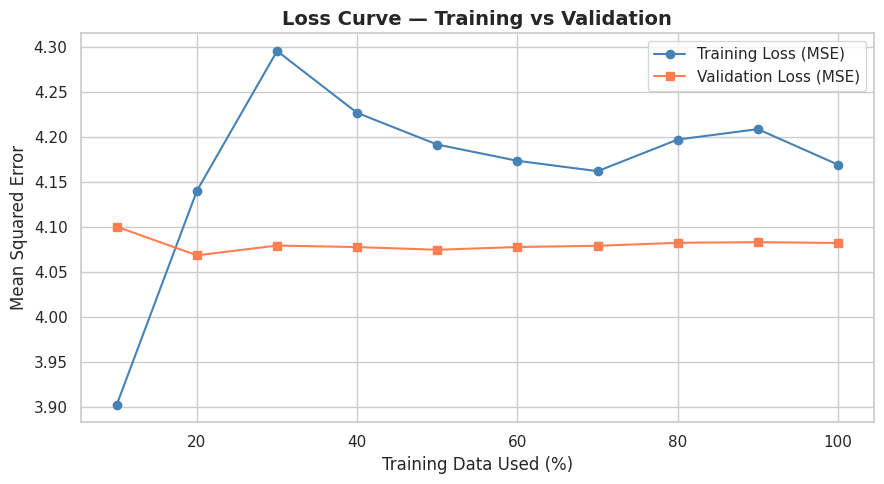

In [40]:

from sklearn.metrics import mean_squared_error

train_sizes = np.linspace(0.1, 1.0, 10)
train_losses = []
val_losses = []

for size in train_sizes:
    n = int(size * len(X_train_scaled))
    model_temp = LinearRegression()
    model_temp.fit(X_train_scaled[:n], y_train.iloc[:n])

    train_pred = model_temp.predict(X_train_scaled[:n])
    val_pred = model_temp.predict(X_test_scaled)

    train_losses.append(mean_squared_error(y_train.iloc[:n], train_pred))
    val_losses.append(mean_squared_error(y_test, val_pred))

plt.figure(figsize=(9, 5))
plt.plot(train_sizes * 100, train_losses, marker='o', label='Training Loss (MSE)', color='steelblue')
plt.plot(train_sizes * 100, val_losses, marker='s', label='Validation Loss (MSE)', color='coral')
plt.xlabel('Training Data Used (%)', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Loss Curve — Training vs Validation', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
comparison = pd.DataFrame({
    'Actual Performance': y_test.values[:10],
    'Predicted Performance': np.round(y_pred[:10], 2),
    'Error': np.round(y_test.values[:10] - y_pred[:10], 2)
})

print("              Sample Predictions (First 10) ")
print(comparison.to_string(index=False))

              Sample Predictions (First 10) 
 Actual Performance  Predicted Performance  Error
               51.0                  54.71  -3.71
               20.0                  22.62  -2.62
               46.0                  47.90  -1.90
               28.0                  31.29  -3.29
               41.0                  43.00  -2.00
               59.0                  59.07  -0.07
               48.0                  45.90   2.10
               87.0                  86.46   0.54
               37.0                  37.70  -0.70
               73.0                  72.06   0.94
